# Разработка модели оценки стоимости автомобилей для AutoValue AI с учетом бизнес-рисков

Автор: Мельников Артём Владимирович

Дата: 04.06.2026

## Цели и задачи проекта

AutoValue AI хочет автоматизировать оценку стоимости подержанных автомобилей. Сейчас оценкой занимаются эксперты вручную: они анализируют характеристики машины, рынок, регион и принимают решение о цене выкупа. Такой подход сложно масштабировать, он зависит от опыта конкретного оценщика и не позволяет быстро обрабатывать большое количество заявок.

Для бизнеса ошибка в оценке напрямую влияет на деньги. Если предложить клиенту слишком высокую цену, компания рискует купить автомобиль дороже его реальной рыночной стоимости. Если предложить слишком низкую цену, клиент может отказаться от сделки и уйти к конкурентам.

Цель проекта - построить модель машинного обучения, которая будет предсказывать рыночную стоимость автомобиля по его характеристикам и поможет AutoValue AI быстрее принимать решение о цене выкупа.

В рамках проекта необходимо:

- провести первичный анализ данных;
- подготовить данные для обучения моделей;
- сравнить три библиотеки градиентного бустинга: XGBoost, CatBoost и LightGBM;
- оценить модели не только по стандартным метрикам регрессии, но и по бизнес-рискам;
- подобрать гиперпараметры моделей с помощью Optuna;
- проанализировать важность признаков с помощью SHAP;
- проверить лучшую модель на отложенной тестовой выборке;
- сформулировать итоговую рекомендацию для бизнеса.

Основная метрика качества для сравнения моделей - MAE, так как она показывает среднюю ошибку прогноза в рублях и понятна бизнесу.

Дополнительно будут использоваться RMSE и R2, а также бизнес-метрики:

- Overpricing Rate - доля случаев, когда модель завысила цену более чем на 20%;
- Underpricing Loss - суммарная потеря в случаях, когда модель занизила цену более чем на 20%.

Для бизнес-метрик задан важный порог ошибки - 20% отклонения прогноза от реальной цены. Также при финальной проверке важно сравнить качество на валидационной и тестовой выборках: если разница метрик будет в пределах 5-10%, модель можно считать стабильной.

## Перевод бизнес-задачи на язык машинного обучения

AutoValue AI необходимо автоматизировать процесс оценки стоимости подержанных автомобилей для последующего выкупа. Бизнес ожидает, что модель сможет быстро и достаточно точно определять рыночную цену автомобиля по его характеристикам, минимизируя финансовые риски компании.

С точки зрения машинного обучения данная задача является задачей регрессии, поскольку требуется предсказать непрерывную числовую величину - стоимость автомобиля в рублях.

Объектом моделирования является отдельный автомобиль, представленный набором характеристик, таких как марка, год выпуска, пробег, объем двигателя, тип топлива, количество владельцев, история обслуживания и другие параметры.

Целевой признак:

- `price_rub` - рыночная стоимость автомобиля в рублях.

Признаки модели:

- `brand`
- `make_year`
- `mileage_kmpl`
- `engine_cc`
- `fuel_type`
- `transmission`
- `owner_count`
- `color`
- `service_history`
- `accidents_reported`
- `insurance_valid`
- `region`

Для решения задачи планируется использовать алгоритмы градиентного бустинга и сравнить возможности трех популярных библиотек:

- XGBoost;
- CatBoost;
- LightGBM.

Качество моделей будет оцениваться как с точки зрения точности прогнозирования, так и с точки зрения бизнес-рисков.

Основная метрика проекта:

- MAE (Mean Absolute Error) - средняя абсолютная ошибка прогноза в рублях.

Дополнительные метрики:

- RMSE (Root Mean Squared Error);
- R² (коэффициент детерминации).

Бизнес-метрики:

- Overpricing Rate - доля случаев, когда прогноз оказался выше реальной стоимости более чем на 20%;
- Underpricing Loss - суммарная величина недооценки в случаях, когда прогноз оказался ниже реальной стоимости более чем на 20%.

Итогом проекта должен стать выбор модели, которая обеспечивает наилучший баланс между точностью прогнозирования стоимости автомобиля и уровнем финансовых рисков для компании.

## Описание данных

В распоряжении есть два файла:

- `ds_s16_train_data.csv` - обучающая выборка с историей 8 000 сделок;
- `ds_s16_test_data.csv` - отложенная тестовая выборка с 2 000 записей.

Файл `ds_s16_train_data.csv` используется для анализа данных, обучения моделей, создания валидационной выборки и подбора гиперпараметров.

Файл `ds_s16_test_data.csv` нельзя использовать при обучении моделей или подборе гиперпараметров. Он нужен только для финальной проверки выбранной модели.

Пути к данным в среде проекта:

- `/datasets/ds_s16_train_data.csv`
- `/datasets/ds_s16_test_data.csv`

Описание признаков:

| Признак | Описание |
|---|---|
| `brand` | Марка автомобиля |
| `make_year` | Год выпуска |
| `mileage_kmpl` | Пробег автомобиля |
| `engine_cc` | Объем двигателя в кубических сантиметрах |
| `fuel_type` | Тип топлива |
| `transmission` | Тип коробки передач |
| `owner_count` | Количество владельцев по ПТС |
| `color` | Цвет автомобиля |
| `service_history` | Наличие сервисной истории |
| `accidents_reported` | Количество зафиксированных ДТП |
| `insurance_valid` | Действительна ли страховка |
| `region` | Макрорегион продажи автомобиля |
| `price_rub` | Рыночная стоимость автомобиля в рублях, целевой признак |

Целевой признак проекта - `price_rub`.

Задача относится к регрессии, так как необходимо предсказать численное значение стоимости автомобиля.

## План работы

Работа над проектом будет выполнена по этапам.

1. EDA - экспресс-анализ данных

На этом этапе загрузим обучающую и тестовую выборки, посмотрим на структуру данных, типы признаков, пропуски и распределение целевого признака `price_rub`. Также проверим корреляции между числовыми признаками.

2. Предобработка данных

Подготовим признаки и целевой признак. Затем сформируем одинаковые обучающую и валидационную выборки для всех трех библиотек, чтобы сравнение моделей было честным. Тестовую выборку оставим только для финальной проверки.

3. Базовое обучение моделей

Обучим XGBoost, CatBoost и LightGBM на базовых настройках. Для каждой модели рассчитаем стандартные метрики регрессии: MAE, RMSE и R2. Также рассчитаем бизнес-метрики Overpricing Rate и Underpricing Loss.

4. Подбор гиперпараметров

Для каждой библиотеки проведем подбор гиперпараметров с помощью Optuna. Основной метрикой оптимизации будет MAE.

5. Интерпретация и бизнес-анализ

Для лучших моделей проведем SHAP-анализ и определим признаки, которые сильнее всего влияют на стоимость автомобиля. Также отдельно изучим ошибки модели через overpricing и underpricing, в том числе в разрезе марок автомобилей и регионов.

6. Финальная проверка

После выбора лучшей модели выполним финальную оценку на отложенной тестовой выборке `ds_s16_test_data.csv`. Сравним результаты на валидации и тесте, чтобы проверить стабильность модели.

7. Итоговый вывод

Подготовим краткую аналитическую записку для AutoValue AI: какая модель показала лучший баланс точности и бизнес-рисков, какие гиперпараметры стоит зафиксировать и где модель требует дополнительного контроля.

# Загрузка библиотек и настройка среды

Для выполнения проекта подготовим рабочее окружение: установим необходимые библиотеки, импортируем инструменты для анализа данных, визуализации, построения моделей и оценки качества.

Также заранее настроим отображение таблиц и графиков, чтобы результаты анализа было удобнее читать.

In [1]:
# Установка совместимых версий библиотек
!pip install -q \
numpy==1.26.4 \
pandas==2.2.2 \
scikit-learn==1.6.1 \
matplotlib==3.8.4 \
seaborn==0.13.2 \
joblib \
optuna \
shap \
phik

# Обновление библиотек градиентного бустинга
!pip install -q --upgrade \
    xgboost \
    lightgbm \
    catboost

In [2]:
# Подключим библиотеки через try|except, чтобы ничего не упало

try:

    # Базовые библиотеки

    import os
    import math

    import numpy as np
    import pandas as pd

    import joblib
    import phik
    import optuna
    import shap
    
    import warnings
    import time

    # Визуализация

    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Дополнительные библиотеки

    from scipy.special import expit

    # Метрики

    from sklearn.metrics import (
        mean_squared_error,
        mean_absolute_error,
        mean_absolute_percentage_error,
        r2_score,
        log_loss,
        make_scorer,
        average_precision_score,
        brier_score_loss,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay
    )

    # Разделение данных и кросс-валидация

    from sklearn.model_selection import (
        train_test_split,
        cross_val_score,
        cross_validate,
        cross_val_predict,
        GridSearchCV,
        StratifiedKFold,
        KFold
    )

    # Предобработка данных

    from sklearn.preprocessing import (
        StandardScaler,
        OneHotEncoder,
        FunctionTransformer
    )

    from sklearn.compose import ColumnTransformer

    from sklearn.pipeline import Pipeline

    from sklearn.impute import SimpleImputer

    # Отбор признаков

    from sklearn.feature_selection import (
        SequentialFeatureSelector as SFS,
        RFE
    )

    # Базовые классы sklearn

    from sklearn.base import (
        BaseEstimator,
        ClassifierMixin,
        TransformerMixin
    )

    # Линейные модели

    from sklearn.linear_model import (
        LinearRegression,
        LogisticRegression,
        Ridge,
        Lasso,
        SGDRegressor
    )

    # Dummy-модели

    from sklearn.dummy import (
        DummyRegressor,
        DummyClassifier
    )

    # Методы ближайших соседей

    from sklearn.neighbors import KNeighborsRegressor

    # Деревья решений

    from sklearn.tree import DecisionTreeRegressor

    # Метод опорных векторов

    from sklearn.svm import SVC

    # Мультиклассовые стратегии

    from sklearn.multiclass import (
        OneVsOneClassifier,
        OneVsRestClassifier
    )

    # Ансамблевые модели

    from sklearn.ensemble import RandomForestClassifier

    # Калибровка вероятностей

    from sklearn.calibration import (
        calibration_curve,
        CalibratedClassifierCV
    )

    # Градиентный бустинг

    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor
    from catboost import CatBoostRegressor

    print('Все библиотеки успешно импортированы')

except ImportError as error:

    print(f'Ошибка импорта: {error}')

Все библиотеки успешно импортированы


In [3]:
# Сохраняем список установленных библиотек
!pip freeze > requirements.txt

**Настройка среды**

In [4]:
# Константы проекта
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_JOBS = -1 # задействуем все ядра для вычислений

# Настройки отображения pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', None)

# Формат отображения чисел
pd.set_option('display.float_format', lambda value: f'{value:.4f}')

# Настройки стиля графиков
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

# тема
sns.set_theme(
    style='whitegrid',
    palette='muted'
)

sns.set_context('notebook')

# Параметры отображения matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Отображение графиков внутри ноутбука
%matplotlib inline

# Отключение предупреждений
#warnings.filterwarnings('ignore')
#optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=FutureWarning)

print('Настройки отображения успешно применены')

Настройки отображения успешно применены


In [5]:
# Вспомогательная функция для подписей над столбцами на графиках

def add_bar_labels(ax, fmt="{:.3f}", offset=0.0):
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height + offset),
            ha="center",
            va="bottom"
        )

In [6]:
# Функция для более удобного отображения агрегированных таблиц

def format_table(dataframe):
    """
    Округляет числовые значения для более удобного отображения.
    Используется только для итоговых таблиц и статистик.
    """

    return dataframe.round(0).astype(int)

# **Часть 1. EDA (Экспресс-анализ данных)**

Проведите краткое исследование, чтобы лучше понимать данные.

**Задание 1.1:**

* Данные: загрузите `ds_s16_train_data.csv` (обучение) и `ds_s16_test_data.csv` (финальный тест). Обратите внимание на то, как прописать путь к данным: `/datasets/ds_s16_train_data.csv` и `/datasets/ds_s16_test_data.csv`
* Проведите краткий EDA: изучите распределение целевой переменной (`price_rub`), проверьте корреляции.

---

Для начала загрузим обучающую и тестовую выборки.

Так как ноутбук может запускаться как в учебной среде Практикума, так и локально, реализуем универсальную функцию загрузки данных. Сначала она будет искать файл в директории `/datasets`, а при отсутствии попробует загрузить его из облачного хранилища.

После загрузки посмотрим на структуру данных, типы признаков, наличие пропусков и дубликатов.

In [7]:
# Функция загрузки данных

def read_data(file_name):
    """
    Загружает датасет локально или из облачного хранилища.
    """

    local_path = f'/datasets/{file_name}'
    cloud_path = f'https://code.s3.yandex.net/datasets/{file_name}'

    try:
        data = pd.read_csv(local_path)
        print(f'Файл {file_name} успешно загружен локально')
        return data

    except FileNotFoundError:

        try:
            data = pd.read_csv(cloud_path)
            print(f'Файл {file_name} успешно загружен из облака')
            return data

        except Exception as error:
            print(f'Ошибка при загрузке файла {file_name}: {error}')
            return None

In [8]:
# Загружаем выборки

train_data = read_data('ds_s16_train_data.csv')
test_data = read_data('ds_s16_test_data.csv')

Файл ds_s16_train_data.csv успешно загружен локально
Файл ds_s16_test_data.csv успешно загружен локально


In [9]:
# Функция краткого обзора датафрейма

def show_dataset_info(dataframe, name):

    print(f'\n{"=" * 60}')
    print(f'{name}')
    print(f'{"=" * 60}')

    display(dataframe.head())

    print('\nРазмер таблицы:')
    print(dataframe.shape)

    print('\nТипы данных:')
    display(dataframe.dtypes)

    print('\nПропуски:')
    display(dataframe.isna().sum())

    print(f'\nКоличество дубликатов: {dataframe.duplicated().sum()}')

In [10]:
show_dataset_info(train_data, 'Обучающая выборка')
show_dataset_info(test_data, 'Тестовая выборка')


Обучающая выборка


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.7000,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.1000,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.5100,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.2700,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.7200,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь



Размер таблицы:
(8000, 13)

Типы данных:


make_year               int64
mileage_kmpl          float64
engine_cc               int64
fuel_type              object
owner_count             int64
brand                  object
transmission           object
color                  object
service_history        object
accidents_reported      int64
insurance_valid        object
price_rub               int64
region                 object
dtype: object


Пропуски:


...


Размер таблицы:
(2000, 13)

Типы данных:


make_year               int64
mileage_kmpl          float64
engine_cc               int64
fuel_type              object
owner_count             int64
brand                  object
transmission           object
color                  object
service_history        object
accidents_reported      int64
insurance_valid        object
price_rub               int64
region                 object
dtype: object


Пропуски:


make_year             0
mileage_kmpl          0
engine_cc             0
fuel_type             0
owner_count           0
brand                 0
transmission          0
color                 0
service_history       0
accidents_reported    0
insurance_valid       0
price_rub             0
region                0
dtype: int64


Количество дубликатов: 0


**Предварительные наблюдения**

Данные успешно загружены.

В обучающей выборке содержится 8 000 наблюдений, в тестовой - 2 000 наблюдений, что соответствует описанию проекта.

Признаки представлены как числовыми, так и категориальными переменными. Целевой признак `price_rub` присутствует в обеих выборках.

На данном этапе проверка показывает отсутствие пропусков и явных дубликатов. Это хороший знак, поскольку позволяет перейти к исследовательскому анализу без дополнительной очистки данных.

Далее изучим распределение целевого признака и посмотрим, насколько сильно различаются цены автомобилей внутри выборки.

**Исследование целевого признака**

Для задачи регрессии особенно важно понять распределение целевой переменной.

Посмотрим на основные статистики стоимости автомобилей, а также визуально оценим распределение цен и наличие потенциальных выбросов.

In [11]:
# Функция форматирования подписей оси X

from matplotlib.ticker import FuncFormatter

def format_thousands(value, position):
    return f'{int(value):,}'.replace(',', ' ')

In [12]:
display(
    format_table(
        train_data['price_rub']
        .describe()
        .to_frame()
    )
)

,price_rub
count,8000
mean,683648
std,264923
min,95000
25%,493857
50%,663866
75%,855056
max,1676525


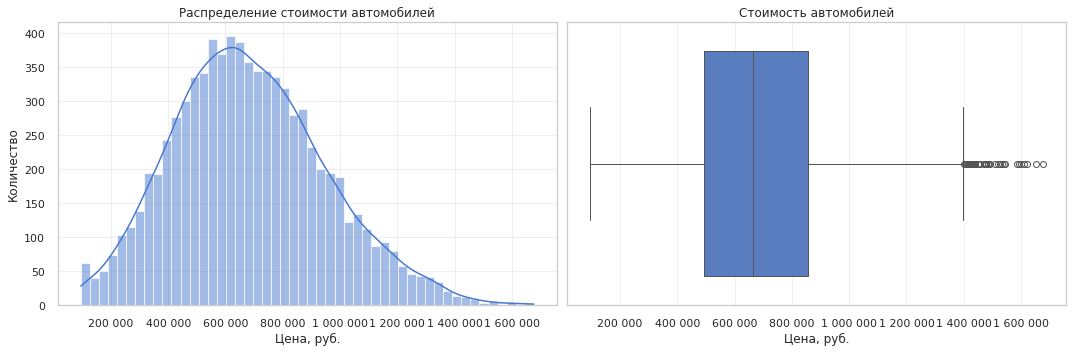

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    train_data['price_rub'],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Распределение стоимости автомобилей')
axes[0].set_xlabel('Цена, руб.')
axes[0].set_ylabel('Количество')
axes[0].xaxis.set_major_formatter(FuncFormatter(format_thousands))

sns.boxplot(
    x=train_data['price_rub'],
    ax=axes[1]
)

axes[1].set_title('Стоимость автомобилей')
axes[1].set_xlabel('Цена, руб.')
axes[1].xaxis.set_major_formatter(FuncFormatter(format_thousands))

plt.tight_layout()
plt.show()

**Вывод**

Стоимость автомобилей распределена неравномерно.

Основная масса наблюдений сосредоточена в среднем ценовом диапазоне, однако присутствуют и более дорогие автомобили, формирующие правый хвост распределения.

На boxplot заметны наблюдения с высокой стоимостью относительно основной массы данных. На текущем этапе нет оснований считать их ошибками или аномалиями, поскольку для рынка автомобилей наличие дорогих моделей является естественным явлением.

Поскольку цель проекта заключается в предсказании стоимости автомобилей любого ценового сегмента, удалять такие наблюдения без дополнительных оснований не будем.

**Анализ взаимосвязей между признаками**

Поскольку в наборе данных присутствуют как числовые, так и категориальные признаки, для оценки связей между ними воспользуемся коэффициентом PhiK.

Этот метод позволяет находить как линейные, так и нелинейные зависимости между признаками разных типов и хорошо подходит для смешанных датасетов.

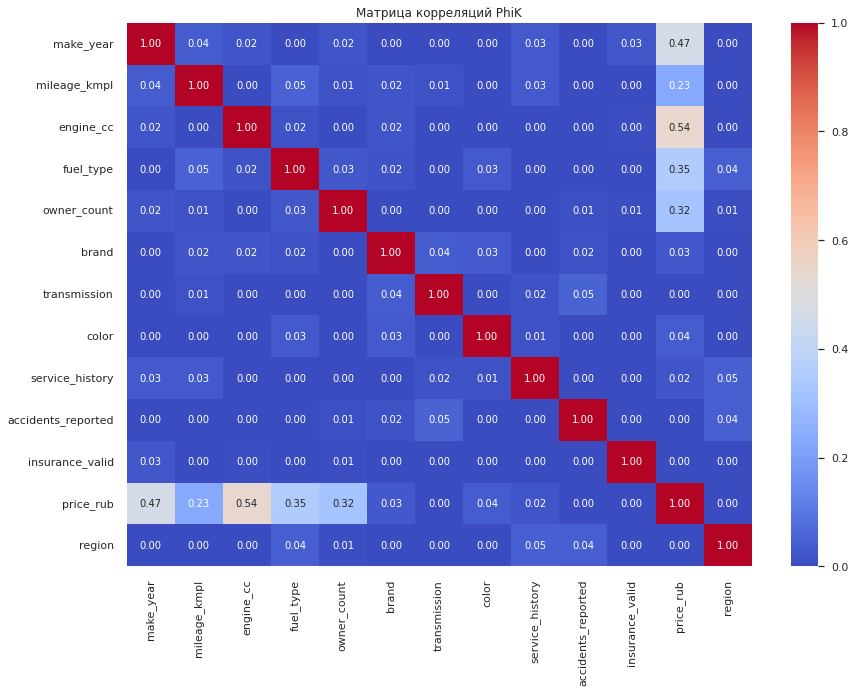

In [14]:
numeric_features = train_data.select_dtypes(include='number').columns.tolist()

phik_corr = train_data.phik_matrix(
    interval_cols=numeric_features
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    phik_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Матрица корреляций PhiK')
plt.show()

In [15]:
strong_relations = (
    phik_corr.where(
        (phik_corr > 0.8) &
        (phik_corr < 1)
    )
)

strong_relations.stack().sort_values(ascending=False)

Series([], dtype: float64)

**Вывод**

По матрице PhiK не наблюдается сильных взаимосвязей между признаками.

Наиболее заметную связь с целевым признаком демонстрируют признаки `engine_cc`, `make_year`, `fuel_type` и `owner_count`, что выглядит логично с точки зрения предметной области.

Высокой корреляции между самими признаками не обнаружено, поэтому оснований для удаления признаков на данном этапе нет.

Также стоит учитывать, что модели градиентного бустинга достаточно устойчивы к умеренной корреляции между признаками, поэтому основное внимание в дальнейшем будет уделяться качеству прогнозов и бизнес-метрикам.

**Первичный бизнес-анализ признаков**

Помимо общего изучения данных полезно посмотреть, как стоимость автомобилей различается между отдельными марками и регионами.

Для AutoValue AI эти признаки потенциально могут оказывать существенное влияние на итоговую цену выкупа. Такой анализ позволит предварительно оценить наличие ценовых различий между сегментами рынка еще до обучения моделей.

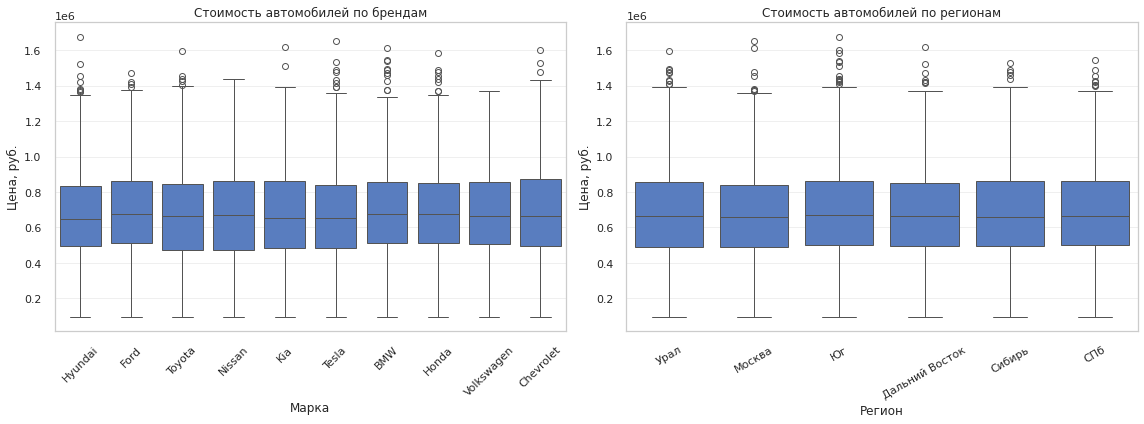

In [16]:
# Распределение стоимости по наиболее представленным брендам и регионам

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Наиболее популярные бренды
popular_brands = train_data['brand'].value_counts().head(12).index

brand_subset = train_data[
    train_data['brand'].isin(popular_brands)
]

sns.boxplot(
    data=brand_subset,
    x='brand',
    y='price_rub',
    ax=axes[0]
)

axes[0].set_title('Стоимость автомобилей по брендам')
axes[0].set_xlabel('Марка')
axes[0].set_ylabel('Цена, руб.')
axes[0].tick_params(axis='x', rotation=45)

# Регионы

sns.boxplot(
    data=train_data,
    x='region',
    y='price_rub',
    ax=axes[1]
)

axes[1].set_title('Стоимость автомобилей по регионам')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Цена, руб.')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [17]:
# Средняя стоимость по брендам

brand_price_stats = (
    train_data
    .groupby('brand')['price_rub']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

display(format_table(brand_price_stats.head(5)))
display(format_table(brand_price_stats.tail(5)))

,mean,median,count
brand,,,
Ford,699378,678090,742
BMW,692037,678124,827
Chevrolet,691261,661910,800
Honda,690464,676352,804
Volkswagen,687766,666482,831


,mean,median,count
brand,,,
Kia,677658,654129,765
Toyota,675791,663090,792
Hyundai,675270,648065,785
Nissan,675254,668361,870
Tesla,672272,650532,784


In [18]:
# Средняя стоимость по регионам

region_price_stats = (
    train_data
    .groupby('region')['price_rub']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

display(format_table(region_price_stats))

,mean,median,count
region,,,
Юг,689466,669221,1408
СПб,686690,667138,1346
Урал,685679,665710,1371
Сибирь,685399,658250,1261
Дальний Восток,679099,663348,1295
Москва,675014,659440,1319


**Вывод**

Уже на этапе первичного анализа заметны различия в стоимости автомобилей между отдельными брендами и регионами.

Распределения цен по брендам показывают, что некоторые марки в среднем продаются дороже других. При этом диапазоны цен внутри большинства брендов достаточно широкие, что говорит о влиянии дополнительных факторов, таких как год выпуска, пробег, состояние автомобиля и история эксплуатации.

Региональные различия присутствуют, однако визуально выглядят менее выраженными, чем различия между брендами. Тем не менее регион продажи может содержать полезную информацию о локальной специфике рынка и поэтому должен быть сохранен для дальнейшего моделирования.

Полученные результаты подтверждают бизнес-логику проекта: стоимость автомобиля формируется под влиянием сразу нескольких факторов, и задача модели будет заключаться в поиске и учете этих зависимостей.

# **Часть 2. Предобработка**

На этом этапе подготовьте данные для честного соревнования библиотек. Помните: качество входных данных определяет предел точности самого мощного алгоритма.

**Задание 2.1:**

* Создайте одинаковые обучающие и валидационные наборы данных для всех трех библиотек.
* Подготовьте признаки для каждой библиотеки.
* Зафиксируйте тест: используйте файл `ds_s16_test_data.csv` как отложенную тестовую выборку.

На этом этапе подготовим данные для дальнейшего сравнения моделей.

Для честного "турнира" между XGBoost, CatBoost и LightGBM важно использовать одинаковые обучающие и валидационные выборки. При этом сами библиотеки работают с категориальными признаками по-разному, поэтому заранее подготовим данные в удобном для них формате.

Отдельно зафиксируем тестовую выборку. Она не будет участвовать в обучении и подборе гиперпараметров и понадобится только для финальной проверки лучшей модели.

In [19]:
# Выделим группы признаков

categorical_features = [
    'fuel_type',
    'brand',
    'transmission',
    'color',
    'service_history',
    'insurance_valid',
    'region'
]

numeric_features = [
    'make_year',
    'mileage_kmpl',
    'engine_cc',
    'owner_count',
    'accidents_reported'
]

In [20]:
# Проверим состав категориальных признаков

for feature in categorical_features:

    print(f'\n{feature}')
    print('-' * len(feature))

    display(
        train_data[feature]
        .value_counts()
    )


fuel_type
---------


fuel_type
Petrol      3990
Diesel      3213
Electric     797
Name: count, dtype: int64


brand
-----


brand
Nissan        870
Volkswagen    831
BMW           827
Honda         804
Chevrolet     800
Toyota        792
Hyundai       785
Tesla         784
Kia           765
Ford          742
Name: count, dtype: int64


transmission
------------


...

service_history
Full       3985
Partial    2362
Unknown    1653
Name: count, dtype: int64


insurance_valid
---------------


insurance_valid
Yes    6356
No     1644
Name: count, dtype: int64


region
------


region
Юг                1408
Урал              1371
СПб               1346
Москва            1319
Дальний Восток    1295
Сибирь            1261
Name: count, dtype: int64

**Вывод**

Все категориальные признаки содержат ограниченное число уникальных значений и подходят для дальнейшего использования в моделях градиентного бустинга.

Редких категорий, которые потребовали бы объединения или дополнительной обработки, на данном этапе не наблюдается.

**Подготовка обучающей, валидационной и тестовой выборок**

Целевой признак проекта - `price_rub`.

Сначала разделим данные на признаки и целевую переменную. После этого сформируем обучающую и валидационную выборки.

Для всех моделей будем использовать одинаковые объекты наблюдений, чтобы сравнение результатов было честным.

При этом библиотеки по-разному работают с категориальными признаками:

- XGBoost требует отдельной подготовки категориальных признаков или использования специальных настроек для работы с ними.
- CatBoost содержит собственные алгоритмы обработки категориальных признаков и способен использовать их без One-Hot Encoding.
- LightGBM также поддерживает работу с категориальными признаками через тип данных `category`.

Поэтому дополнительно подготовим версии датафреймов, в которых категориальные признаки будут иметь тип `category`. Эти данные будут использоваться при работе с CatBoost и LightGBM.

In [21]:
# Разделяем признаки и целевую переменную

features = train_data.drop(columns='price_rub')
target = train_data['price_rub']

features_test = test_data.drop(columns='price_rub')
target_test = test_data['price_rub']

In [22]:
# Формируем обучающую и валидационную выборки

X_train, X_valid, y_train, y_valid = train_test_split(
    features,
    target,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

In [23]:
# Функция перевода признаков в тип category

def convert_to_category(dataframe, columns):

    data = dataframe.copy()

    for column in columns:
        data[column] = data[column].astype('category')

    return data

In [24]:
# Данные для CatBoost и LightGBM
# Версии данных с типом category

X_train_cat = convert_to_category(
    X_train,
    categorical_features
)

X_valid_cat = convert_to_category(
    X_valid,
    categorical_features
)

X_test_cat = convert_to_category(
    features_test,
    categorical_features
)

In [25]:
# Проверим, что категориальные признаки получили тип category

display(
    X_train_cat[categorical_features]
    .dtypes
)

fuel_type          category
brand              category
transmission       category
color              category
service_history    category
insurance_valid    category
region             category
dtype: object

Все категориальные признаки успешно переведены в тип `category`.

Это позволит использовать встроенные механизмы обработки категориальных признаков в CatBoost и LightGBM без дополнительного кодирования на текущем этапе.

In [26]:
# Проверка размеров
print('Обучающая выборка:', X_train.shape)
print('Валидационная выборка:', X_valid.shape)
print('Тестовая выборка:', features_test.shape)

print('\nЦелевая переменная:')
print('y_train:', y_train.shape)
print('y_valid:', y_valid.shape)
print('y_test:', target_test.shape)

Обучающая выборка: (6400, 12)
Валидационная выборка: (1600, 12)
Тестовая выборка: (2000, 12)

Целевая переменная:
y_train: (6400,)
y_valid: (1600,)
y_test: (2000,)


**Вывод**

На этапе предобработки были выделены числовые и категориальные признаки, после чего данные были разделены на обучающую и валидационную выборки.

Тестовая выборка сохранена отдельно и не будет использоваться при обучении моделей и подборе гиперпараметров.

Дополнительно подготовлены версии данных с типом `category`, которые понадобятся для корректной работы CatBoost и LightGBM.

Таким образом, данные готовы к первому этапу соревнования моделей.


# **Часть 3. Обучение моделей в разных библиотеках**

Проверьте, как алгоритмы работают из коробки. Это покажет их естественную предрасположенность к вашему набору данных до начала тонкой настройки.

**Задание 3.1:**

* Обучите XGBoost, CatBoost и LightGBM на стандартных настройках.
* Установите для всех моделей `random_state=42`. В качестве целевой функции используйте MAE.
* Обучите каждую модель
* Задача со звёздочкой: замерьте время обучения и предсказания (Wall time) с помощью `%%time` или модуля `time`.

**Задание 3.2: Сравнение метрик**

* Рассчитайте математические метрики: MAE, RMSE, $R^2$.
* Рассчитайте бизнес-риски: Overpricing Rate (>20%) и Underpricing Loss (>20%).
* Сформулируйте гипотезу: какая библиотека на этом этапе кажется наиболее безопасной для бюджета компании?

**Задача со звёздочкой: модель с использованием Quantile Loss (квантильной регрессии) в CatBoost**

Что нужно сделать:

* Выберите библиотеку `CatBoost`. Реализуйте осторожную модель через квантильный лосс.
* Вместо стандартной функции потерь (MAE) установите `loss_function='Quantile'`.
* Настройте параметр квантиля. Достаточно при инициализации модели указать: `'Quantile:alpha=значение'`. Протестируйте разные значения, выберите оптимальное.
* Сравните результаты этой осторожной модели с базовой (обученной с помощью MAE):
  1. Насколько снизился Overpricing Rate?
  2. Насколько при этом вырос Underpricing Loss?
  3. Готовы ли вы рекомендовать такую безопасную модель Артёму (CEO) вместо самой точной базовой (обученной с помощью MAE)?

---

После подготовки данных можно переходить к первому раунду сравнения моделей.

На этом этапе нас интересует, как XGBoost, LightGBM и CatBoost работают "из коробки", без подбора гиперпараметров. Такой эксперимент позволит понять исходный потенциал каждой библиотеки и определить отправную точку для дальнейшей оптимизации.

Помимо стандартных метрик качества будем оценивать бизнес-метрики проекта:

- Overpricing Rate - доля случаев, когда модель завысила стоимость автомобиля более чем на 20%.
- Underpricing Loss - суммарная упущенная выгода в случаях, когда цена была занижена более чем на 20%.

Дополнительно замерим время обучения и получения прогнозов, поскольку скорость работы модели также важна для будущего мобильного приложения AutoValue AI.

In [27]:
# Таблица для хранения результатов моделей

base_models_results = pd.DataFrame(
    columns=[
        'MAE',
        'RMSE',
        'R2',
        'Overpricing Rate',
        'Underpricing Loss',
        'Train Time (sec)',
        'Predict Time (sec)'
    ]
)

In [28]:
#функция бизнес-метрик
def calculate_business_metrics(y_true, y_pred):
    """
    Расчет бизнес-метрик проекта.
    """

    error_ratio = (y_pred - y_true) / y_true

    overpricing_rate = (error_ratio > 0.20).mean()

    underpricing_mask = error_ratio < -0.20

    underpricing_loss = (
        y_true[underpricing_mask]
        - y_pred[underpricing_mask]
    ).sum()

    return overpricing_rate, underpricing_loss

In [29]:
# Основная функция оценки модели

def evaluate_model(
    model,
    model_name,
    X_train,
    y_train,
    X_valid,
    y_valid,
    fit_params=None
):

    # Обучение модели и расчет всех метрик.

    if fit_params is None:
        fit_params = {}

    start_train = time.time()

    model.fit(
        X_train,
        y_train,
        **fit_params
    )

    train_time = time.time() - start_train

    start_predict = time.time()

    predictions = model.predict(X_valid)

    predict_time = time.time() - start_predict

    mae = mean_absolute_error(
        y_valid,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            predictions
        )
    )

    r2 = r2_score(
        y_valid,
        predictions
    )

    overpricing_rate, underpricing_loss = (
        calculate_business_metrics(
            y_valid,
            predictions
        )
    )

    base_models_results.loc[model_name] = [
        mae,
        rmse,
        r2,
        overpricing_rate,
        underpricing_loss,
        train_time,
        predict_time
    ]

    return predictions

**XGBoost**

Начнем сравнение с XGBoost. Для базовой модели будем использовать встроенную поддержку категориальных признаков и оптимизацию по MAE.

In [30]:
# Базовая модель XGBoost
# Используем встроенную поддержку категориальных признаков

xgb_base = XGBRegressor(
    random_state=RANDOM_STATE,
    objective='reg:absoluteerror',
    eval_metric='mae',
    enable_categorical=True
)

In [31]:
xgb_predictions = evaluate_model(
    model=xgb_base,
    model_name='XGBoost',
    X_train=X_train_cat,
    y_train=y_train,
    X_valid=X_valid_cat,
    y_valid=y_valid
)

display(
    base_models_results
    .sort_values('MAE')
)

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (sec),Predict Time (sec)
XGBoost,85486.9609,107962.6270,0.8279,0.1444,23654384.2188,0.3112,0.0164


**LightGBM**

Следующим протестируем LightGBM на базовых параметрах и посмотрим, сможет ли он превзойти результат XGBoost.

In [32]:
# Базовая модель LightGBM
# Оптимизация выполняется по MAE

lgbm_base = LGBMRegressor(
    random_state=RANDOM_STATE,
    objective='mae',
    metric='mae'
)

In [33]:
lgbm_predictions = evaluate_model(
    model=lgbm_base,
    model_name='LightGBM',
    X_train=X_train_cat,
    y_train=y_train,
    X_valid=X_valid_cat,
    y_valid=y_valid,
    fit_params={
        'categorical_feature': categorical_features
    }
)

display(
    base_models_results
    .sort_values('MAE')
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 347
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 12
[LightGBM] [Info] Start training from score 662700.500000


,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (sec),Predict Time (sec)
LightGBM,81979.3054,102803.9320,0.8439,0.1394,19556105.1000,0.1500,0.0174
XGBoost,85486.9609,107962.6270,0.8279,0.1444,23654384.2188,0.3112,0.0164


**CatBoost**

CatBoost изначально создавался для работы с категориальными признаками, поэтому особенно интересно посмотреть его результат без дополнительной настройки.

In [34]:
# Базовая модель CatBoost
# Используем встроенную работу с категориальными признаками

catboost_base = CatBoostRegressor(
    random_state=RANDOM_STATE,
    loss_function='MAE',
    eval_metric='MAE',
    use_best_model=True,
    verbose=False
)

In [35]:
catboost_predictions = evaluate_model(
    model=catboost_base,
    model_name='CatBoost',
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    fit_params={
        'eval_set': (X_valid, y_valid),
        'cat_features': categorical_features
    }
)

In [36]:
# Табилица результатов

display(
    base_models_results
    .sort_values('MAE')
    .round(4)
)

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (sec),Predict Time (sec)
CatBoost,79343.1747,99021.6340,0.8552,0.1338,16566048.3223,11.7375,0.0065
LightGBM,81979.3054,102803.9320,0.8439,0.1394,19556105.1000,0.1500,0.0174
XGBoost,85486.9609,107962.6270,0.8279,0.1444,23654384.2188,0.3112,0.0164


**Вывод**

По результатам первого этапа сравнения лучшей моделью оказалась CatBoost.

Она показала минимальную среднюю абсолютную ошибку (79 343 руб.), а также лучшие значения RMSE и R² среди протестированных библиотек.

С точки зрения бизнес-метрик CatBoost также выглядит наиболее безопасным вариантом:

- Overpricing Rate составил 13.4%, что является лучшим результатом среди базовых моделей;
- Underpricing Loss составил около 16.6 млн руб., что заметно ниже, чем у LightGBM и XGBoost.

LightGBM занял второе место и продемонстрировал достойное качество прогнозов при очень высокой скорости обучения.

XGBoost показал самые слабые результаты как по качеству прогнозирования, так и по бизнес-метрикам.

По сравнению с LightGBM средняя ошибка CatBoost оказалась ниже примерно на 2.6 тыс. руб., а упущенная выгода меньше почти на 3 млн руб.

По сравнению с XGBoost преимущество еще заметнее: MAE ниже более чем на 6 тыс. руб., а Underpricing Loss меньше почти на 7 млн руб.

Интересно отметить различия по скорости работы моделей. Самым быстрым по обучению оказался LightGBM, тогда как CatBoost потребовал существенно больше времени на обучение. Однако время предсказания у CatBoost оказалось минимальным, что может быть важным преимуществом для будущего мобильного приложения.

На текущем этапе именно CatBoost выглядит наиболее перспективным кандидатом для дальнейшего подбора гиперпараметров и углубленного анализа.

# **Часть 4. Работа с параметрами модели (Тюнинг)**

Теперь ваша задача — заставить алгоритмы работать на пределе возможностей, подбирая ключи к их гиперпараметрам. Чтобы сравнение было объективным, используйте единую стратегию поиска для всех библиотек.

**Задание 4.1:**

* Настройте поиск в Optuna для каждой модели.
* Использьзуйте сетку параметров, предложенную в описании проекта:
  1. **Общая сетка для всех моделей:**
    * Скорость обучения (`learning_rate/eta`): от `0.01` до `0.1, log=True`.
    * Глубина дерева (`max_depth/depth`): от `3` до `10`.
    * Количество итераций (`n_estimators/iterations`): зафиксируйте в диапазоне `500–2000`.
  2. **Специфические параметры (регуляризация):**
  * Для XGBoost: добавьте параметры `gamma` (от `1e-8` до `1.0`) и `reg_lambda/reg_alpha`(от `1e-8` до `10.0`).
  * Для CatBoost: используйте `l2_leaf_reg` (от `1` до `10`).
  * Для LightGBM: добавьте `num_leaves` (от `20` до `256`) и `min_child_samples` (от `5` до `100`); `reg_alpha` и `reg_lambda` от `1e-8` до `1.0`.
  3. Не забудьте `"random_seed": 42` и `MAE` .

* Проведите поиск гиперпараметров с помощью Optuna.
---


Базовые модели уже показали достаточно хорошие результаты, однако градиентный бустинг особенно чувствителен к настройке гиперпараметров.

На этом этапе воспользуемся библиотекой Optuna и попробуем подобрать более удачные комбинации параметров для каждой модели. Поиск будем проводить в диапазонах, рекомендованных в задании проекта.

Для XGBoost и LightGBM будем использовать Optuna совместно с кросс-валидацией. Такой подход позволяет оценивать качество модели сразу на нескольких разбиениях обучающей выборки и снижает риск подбора параметров под конкретную валидационную выборку.

Для CatBoost поиск параметров выполним на заранее выделенной валидационной выборке, чтобы корректно использовать встроенную обработку категориальных признаков.

Такой подход позволяет оценивать качество модели сразу на нескольких разбиениях обучающей выборки и снижает риск подбора параметров под конкретную валидационную выборку.

В качестве целевой метрики используем MAE, поскольку именно она применялась при обучении базовых моделей и соответствует требованиям проекта.

После завершения поиска лучшие параметры будут использованы для обучения модели на обучающей выборке, а итоговая оценка качества будет выполнена на ранее выделенной валидационной выборке.

In [37]:
# Количество испытаний Optuna

N_TRIALS = 10

In [38]:
# Универсальная функция запуска Optuna
# Возвращает лучшие найденные параметры

def run_optuna(objective_function):

    sampler = optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    study.optimize(
        objective_function,
        n_trials=N_TRIALS,
        show_progress_bar=True
    )

    print('\nЛучшие параметры:')

    for parameter, value in study.best_params.items():
        print(f'{parameter}: {value}')

    print(
        f'\nЛучшее значение MAE: '
        f'{study.best_value:,.2f}'
    )

    return study.best_params

**Настройка XGBoost**

Для XGBoost дополнительно настроим параметры регуляризации gamma, reg_alpha и reg_lambda. Они позволяют контролировать сложность модели и помогают бороться с переобучением.

In [39]:
# Целевая функция Optuna для XGBoost
# Подбор параметров выполняется по MAE на кросс-валидации

def objective_xgb(trial):

    params = {

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.1,
            log=True
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            10
        ),

        'n_estimators': trial.suggest_int(
            'n_estimators',
            500,
            2000
        ),

        'gamma': trial.suggest_float(
            'gamma',
            1e-8,
            1.0,
            log=True
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            1e-8,
            10.0,
            log=True
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            1e-8,
            10.0,
            log=True
        )
    }

    model = XGBRegressor(
        random_state=RANDOM_STATE,
        objective='reg:absoluteerror',
        eval_metric='mae',
        enable_categorical=True,
        **params
    )

    scores = cross_val_score(
        model,
        X_train_cat,
        y_train,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    return -scores.mean()

In [40]:
# Поиск лучших параметров XGBoost

best_xgb_params = run_optuna(
    objective_xgb
)

[I 2026-06-04 07:33:53,817] A new study created in memory with name: no-name-8973cb25-02f7-4341-9983-fdf7667374f1


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-04 07:34:24,994] Trial 0 finished with value: 81856.40625 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'gamma': 0.0006155564318973012, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}. Best is trial 0 with value: 81856.40625.
[I 2026-06-04 07:34:46,518] Trial 1 finished with value: 81101.84375 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 9, 'n_estimators': 1402, 'gamma': 0.004619347374377372, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 5.360294728728285}. Best is trial 1 with value: 81101.84375.
[I 2026-06-04 07:34:49,670] Trial 2 finished with value: 78662.22916666667 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 2.9324868872723725e-07, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 2 with value: 78662.22916666667.
[I 2026-06-04 07:34:56,307] Trial 3 finished with value: 79207

In [41]:
# Обучение модели с найденными параметрами

tuned_xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    objective='reg:absoluteerror',
    eval_metric='mae',
    enable_categorical=True,
    **best_xgb_params
)

evaluate_model(
    model=tuned_xgb,
    model_name='Tuned XGBoost',
    X_train=X_train_cat,
    y_train=y_train,
    X_valid=X_valid_cat,
    y_valid=y_valid
)

display(
    base_models_results
    .sort_values('MAE')
)

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (sec),Predict Time (sec)
CatBoost,79343.1747,99021.6340,0.8552,0.1338,16566048.3223,11.7375,0.0065
Tuned XGBoost,80408.7812,101017.7610,0.8493,0.1344,19160886.5312,2.5862,0.0504
LightGBM,81979.3054,102803.9320,0.8439,0.1394,19556105.1000,0.1500,0.0174
XGBoost,85486.9609,107962.6270,0.8279,0.1444,23654384.2188,0.3112,0.0164


**Настройка LightGBM**

Для LightGBM кроме основных параметров дерева настроим количество листьев, минимальное число объектов в листе и параметры регуляризации.

In [42]:
# Целевая функция Optuna для LightGBM
# Качество оценивается по средней MAE на трех фолдах

def objective_lgbm(trial):

    params = {

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.1,
            log=True
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            10
        ),

        'n_estimators': trial.suggest_int(
            'n_estimators',
            500,
            2000
        ),

        'num_leaves': trial.suggest_int(
            'num_leaves',
            20,
            256
        ),

        'min_child_samples': trial.suggest_int(
            'min_child_samples',
            5,
            100
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            1e-8,
            1.0
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            1e-8,
            1.0
        )
    }

    model = LGBMRegressor(
        random_state=RANDOM_STATE,
        objective='mae',
        metric='mae',
        verbose=-1,
        **params
    )

    scores = cross_val_score(
        model,
        X_train_cat,
        y_train,
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    return -scores.mean()

In [43]:
# Поиск лучших параметров LightGBM

best_lgbm_params = run_optuna(
    objective_lgbm
)

[I 2026-06-04 07:35:57,418] A new study created in memory with name: no-name-a6040e9f-58f9-4a35-892e-027e84d9d3f4


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-04 07:36:12,396] Trial 0 finished with value: 80199.57608193411 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'num_leaves': 161, 'min_child_samples': 19, 'reg_alpha': 0.15599452877625744, 'reg_lambda': 0.05808362158736334}. Best is trial 0 with value: 80199.57608193411.
[I 2026-06-04 07:36:18,263] Trial 1 finished with value: 80341.76787988575 and parameters: {'learning_rate': 0.07348118405270448, 'max_depth': 7, 'n_estimators': 1562, 'num_leaves': 24, 'min_child_samples': 98, 'reg_alpha': 0.8324426424759953, 'reg_lambda': 0.21233911855488502}. Best is trial 0 with value: 80199.57608193411.
[I 2026-06-04 07:36:20,593] Trial 2 finished with value: 78201.08936035215 and parameters: {'learning_rate': 0.015199348301309814, 'max_depth': 4, 'n_estimators': 956, 'num_leaves': 144, 'min_child_samples': 46, 'reg_alpha': 0.2912291472857505, 'reg_lambda': 0.6118528986038505}. Best is trial 2 with value: 78201.08936035215.
[I 2026-06-04 0

In [44]:
# Обучение модели с найденными параметрами

tuned_lgbm = LGBMRegressor(
    random_state=RANDOM_STATE,
    objective='mae',
    metric='mae',
    verbose=-1,
    **best_lgbm_params
)

evaluate_model(
    model=tuned_lgbm,
    model_name='Tuned LightGBM',
    X_train=X_train_cat,
    y_train=y_train,
    X_valid=X_valid_cat,
    y_valid=y_valid,
    fit_params={
        'categorical_feature': categorical_features
    }
)

display(
    base_models_results
    .sort_values('MAE')
)

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (sec),Predict Time (sec)
CatBoost,79343.1747,99021.6340,0.8552,0.1338,16566048.3223,11.7375,0.0065
Tuned XGBoost,80408.7812,101017.7610,0.8493,0.1344,19160886.5312,2.5862,0.0504
Tuned LightGBM,80749.4743,101181.5562,0.8488,0.1350,19749509.5877,0.9026,0.1466
LightGBM,81979.3054,102803.9320,0.8439,0.1394,19556105.1000,0.1500,0.0174
XGBoost,85486.9609,107962.6270,0.8279,0.1444,23654384.2188,0.3112,0.0164


**Настройка CatBoost**

Для CatBoost подберем скорость обучения, глубину деревьев, количество итераций и коэффициент регуляризации L2.

Для CatBoost поиск параметров будем выполнять на заранее выделенной валидационной выборке. Такой подход позволяет корректно использовать встроенную обработку категориальных признаков и соответствует рекомендациям библиотеки.

In [47]:
# Целевая функция Optuna для CatBoost
# Подбор выполняется по MAE на валидационной выборке

def objective_catboost(trial):

    params = {

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.1,
            log=True
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            10
        ),

        'n_estimators': trial.suggest_int(
            'n_estimators',
            500,
            2000
        ),

        'l2_leaf_reg': trial.suggest_int(
            'l2_leaf_reg',
            1,
            10
        )
    }

    model = CatBoostRegressor(
        random_state=RANDOM_STATE,
        loss_function='MAE',
        eval_metric='MAE',
        verbose=False,
        use_best_model=True,
        **params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=categorical_features
    )

    predictions = model.predict(
        X_valid
    )

    return mean_absolute_error(
        y_valid,
        predictions
    )

In [48]:
# Поиск лучших параметров CatBoost

best_catboost_params = run_optuna(
    objective_catboost
)

[I 2026-06-04 07:40:25,791] A new study created in memory with name: no-name-34c86bad-dd64-42ed-a192-43d0d7f3bf99


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-04 07:41:15,517] Trial 0 finished with value: 79989.792134146 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'l2_leaf_reg': 6}. Best is trial 0 with value: 79989.792134146.
[I 2026-06-04 07:41:22,595] Trial 1 finished with value: 79665.63966555332 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 4, 'n_estimators': 587, 'l2_leaf_reg': 9}. Best is trial 1 with value: 79665.63966555332.
[I 2026-06-04 07:41:31,017] Trial 2 finished with value: 79607.92044305473 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 8, 'n_estimators': 530, 'l2_leaf_reg': 10}. Best is trial 2 with value: 79607.92044305473.
[I 2026-06-04 07:41:39,321] Trial 3 finished with value: 79040.53086582925 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'l2_leaf_reg': 2}. Best is trial 3 with value: 79040.53086582925.
[I 2026-06-04 07:41:53,259] Trial 4 finished with value: 79635.328

In [49]:
# Обучение модели с найденными параметрами

tuned_catboost = CatBoostRegressor(
    random_state=RANDOM_STATE,
    loss_function='MAE',
    eval_metric='MAE',
    verbose=False,
    use_best_model=True,
    **best_catboost_params
)

evaluate_model(
    model=tuned_catboost,
    model_name='Tuned CatBoost',
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    fit_params={
        'eval_set': (X_valid, y_valid),
        'cat_features': categorical_features
    }
)

display(
    base_models_results
    .sort_values('MAE')
)

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (sec),Predict Time (sec)
Tuned CatBoost,79040.5309,98726.1374,0.8561,0.1350,17445162.1641,8.2001,0.0046
CatBoost,79343.1747,99021.6340,0.8552,0.1338,16566048.3223,11.7375,0.0065
Tuned XGBoost,80408.7812,101017.7610,0.8493,0.1344,19160886.5312,2.5862,0.0504
Tuned LightGBM,80749.4743,101181.5562,0.8488,0.1350,19749509.5877,0.9026,0.1466
LightGBM,81979.3054,102803.9320,0.8439,0.1394,19556105.1000,0.1500,0.0174
XGBoost,85486.9609,107962.6270,0.8279,0.1444,23654384.2188,0.3112,0.0164


In [50]:
# Сравнение всех протестированных моделей

display(
    base_models_results
    .sort_values('MAE')
    .round(4)
)

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (sec),Predict Time (sec)
Tuned CatBoost,79040.5309,98726.1374,0.8561,0.1350,17445162.1641,8.2001,0.0046
CatBoost,79343.1747,99021.6340,0.8552,0.1338,16566048.3223,11.7375,0.0065
Tuned XGBoost,80408.7812,101017.7610,0.8493,0.1344,19160886.5312,2.5862,0.0504
Tuned LightGBM,80749.4743,101181.5562,0.8488,0.1350,19749509.5877,0.9026,0.1466
LightGBM,81979.3054,102803.9320,0.8439,0.1394,19556105.1000,0.1500,0.0174
XGBoost,85486.9609,107962.6270,0.8279,0.1444,23654384.2188,0.3112,0.0164


**Вывод**

Подбор гиперпараметров позволил улучшить качество всех трех моделей по сравнению с базовыми версиями.

Наибольший относительный прирост показали XGBoost и LightGBM. После настройки они заметно сократили отставание от лидера по MAE и другим метрикам качества.

Лучший результат по точности продемонстрировал Tuned CatBoost:

- MAE снизилась с 79 343 до 79 041 руб.;
- RMSE уменьшилась с 99 022 до 98 726 руб.;
- R² выросла с 0.855 до 0.856.

При этом улучшение математических метрик сопровождалось небольшим ростом бизнес-рисков: Overpricing Rate увеличился с 13.38% до 13.50%, а Underpricing Loss вырос примерно на 0.88 млн руб.

Несмотря на небольшой рост бизнес-рисков, Tuned CatBoost остается лидером по точности прогнозирования. При дальнейшем выборе модели нужно учитывать компромисс: базовый CatBoost немного безопаснее по Overpricing Rate и Underpricing Loss, а Tuned CatBoost точнее по MAE, RMSE и R².

На следующем этапе именно эту модель целесообразно использовать для дальнейшего анализа и проверки на отложенной тестовой выборке.

# **Часть 5. Интерпретация и бизнес-анализ**

Модель должна быть прозрачной. Ваша задача — убедиться, что алгоритм принимает решения на основе рыночных факторов, а не случайных корреляций.

**Задание 5.1:**

* Постройте SHAP Summary Plot для оптимизированных моделей после поиска Optuna.
* Проанализируйте:
  1. Какие Топ-5 признаков вносят наибольший вклад в цену автомобиля?
  2. Совпадают ли выводы модели с бизнес-логикой?
  3. Как специфические признаки (например, color или insurance_valid) влияют на предсказание?

**Задание 5.2**

Используйте введённые метрики Overpricing Rate и Underpricing Loss:
* Рассчитайте долю завышений и недооценок для каждой модели.
* Сравните модели не только по MAE и RMSE, но и по бизнес-рискам.

**Задание 5.3**

* Проанализируйте ошибки в разрезе категорий (марки автомобилей и макро-регионов).
* Выявите марки машин и регионы, где риск ошибки высок — это зоны, где в будущем потребуется ручная проверка экспертом.

---

Высокая точность модели сама по себе еще не гарантирует, что ей можно доверять в реальной работе.

На этом этапе важно понять, какие факторы влияют на стоимость автомобиля, насколько выводы модели соответствуют здравому смыслу и какие бизнес-риски сохраняются даже после настройки гиперпараметров.

Для этого:

- проанализируем важность признаков с помощью SHAP;
- сравним модели с точки зрения бизнес-метрик;
- найдем марки автомобилей и регионы, где модель ошибается чаще всего.

Такой анализ позволит оценить не только качество прогнозов, но и практическую пригодность модели для использования в сервисе AutoValue AI.

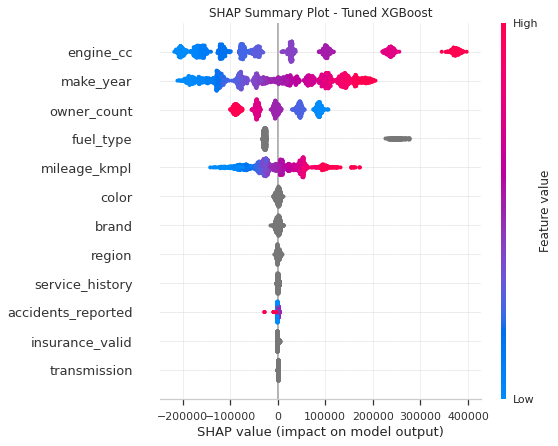

In [51]:
# SHAP-анализ для настроенной модели XGBoost

explainer_xgb = shap.TreeExplainer(tuned_xgb)

shap_values_xgb = explainer_xgb.shap_values(
    X_valid_cat
)

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_xgb,
    X_valid_cat,
    show=False
)

plt.title(
    'SHAP Summary Plot - Tuned XGBoost'
)

plt.tight_layout()
plt.show()

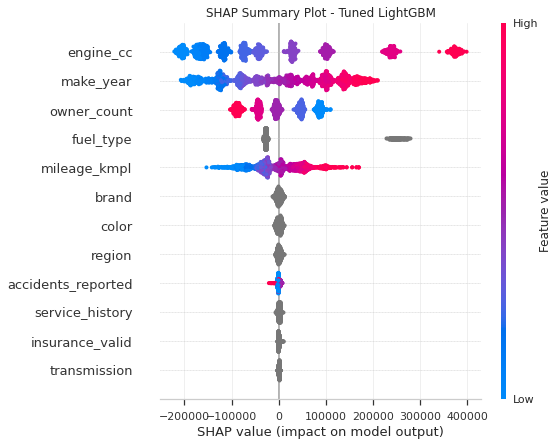

In [52]:
# SHAP-анализ для настроенной модели LightGBM

explainer_lgbm = shap.TreeExplainer(
    tuned_lgbm
)

shap_values_lgbm = explainer_lgbm.shap_values(
    X_valid_cat
)

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_lgbm,
    X_valid_cat,
    show=False
)

plt.title(
    'SHAP Summary Plot - Tuned LightGBM'
)

plt.tight_layout()
plt.show()

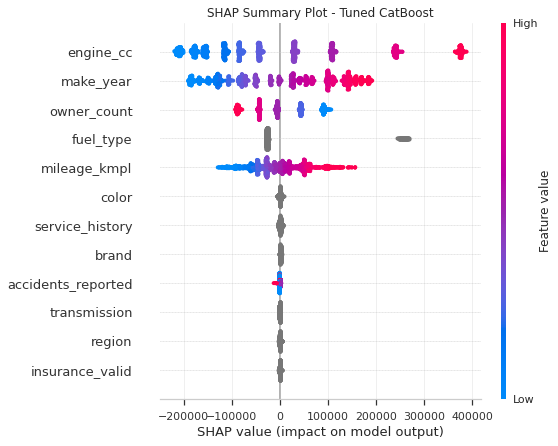

In [53]:
# SHAP-анализ для лучшей модели CatBoost

explainer_catboost = shap.TreeExplainer(
    tuned_catboost
)

shap_values_catboost = explainer_catboost.shap_values(
    X_valid
)

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_catboost,
    X_valid,
    show=False
)

plt.title(
    'SHAP Summary Plot - Tuned CatBoost'
)

plt.tight_layout()
plt.show()

In [54]:
# Получение топ-5 признаков
# Выделим наиболее важные признаки по среднему абсолютному значению SHAP

feature_importance = pd.DataFrame({
    'feature': X_valid.columns,
    'importance': np.abs(
        shap_values_catboost
    ).mean(axis=0)
})

feature_importance = (
    feature_importance
    .sort_values(
        'importance',
        ascending=False
    )
)

display(
    feature_importance.head(10)
)

,feature,importance
2,engine_cc,147735.7429
0,make_year,102926.8293
4,owner_count,53032.9411
3,fuel_type,50133.5232
1,mileage_kmpl,45854.0483
7,color,1567.2774
8,service_history,1371.1629
5,brand,945.4221
9,accidents_reported,907.2601
6,transmission,892.4734


Примечательно, что признаки accidents_reported, insurance_valid и color показали значительно меньший вклад в итоговое предсказание. Вероятно, информация об общем состоянии автомобиля уже частично отражается через более сильные признаки, такие как пробег, количество владельцев и год выпуска.

**Анализ SHAP**

Все три модели показывают схожую картину важности признаков, что дополнительно повышает доверие к результатам.

Наибольший вклад в стоимость автомобиля вносят следующие признаки:

- объем двигателя (`engine_cc`);
- год выпуска автомобиля (`make_year`);
- количество предыдущих владельцев (`owner_count`);
- тип топлива (`fuel_type`);
- показатели пробега (`mileage_kmpl`).

Именно эти признаки формируют основную часть предсказания модели.

Полученные результаты хорошо согласуются с бизнес-логикой рынка автомобилей.

Более новые автомобили обычно стоят дороже, а увеличение объема двигателя положительно влияет на стоимость. Напротив, рост количества владельцев снижает цену автомобиля, поскольку может восприниматься покупателями как дополнительный риск.

Интересно, что в число наиболее значимых факторов также вошел тип топлива (`fuel_type`). Это говорит о том, что рынок по-разному оценивает автомобили с бензиновыми, дизельными и другими типами двигателей.

Отдельного внимания заслуживают признаки `color` и `insurance_valid`, которые были приведены в задании как примеры потенциально важных факторов.

SHAP-анализ показал, что их вклад в итоговое предсказание минимален. Это означает, что модель практически не опирается на цвет автомобиля или наличие действующей страховки при определении рыночной стоимости.

С точки зрения бизнеса такой результат выглядит логичным: техническое состояние автомобиля и его эксплуатационные характеристики оказывают значительно большее влияние на цену, чем подобные второстепенные признаки.

**Сравнение моделей по бизнес-рискам**

Помимо математических метрик важно оценить последствия ошибок для бизнеса.

Для сервиса оценки автомобилей наиболее опасны два сценария:

- завышение стоимости автомобиля более чем на 20% (Overpricing Rate);
- существенная недооценка автомобиля, приводящая к потере потенциальной прибыли (Underpricing Loss).

Результаты расчета этих метрик были получены на предыдущих этапах обучения моделей.

In [55]:
# Сравнение моделей по бизнес-метрикам

display(
    base_models_results[
        [
            'MAE',
            'Overpricing Rate',
            'Underpricing Loss'
        ]
    ]
    .sort_values('MAE')
    .round(4)
)

,MAE,Overpricing Rate,Underpricing Loss
Tuned CatBoost,79040.5309,0.1350,17445162.1641
CatBoost,79343.1747,0.1338,16566048.3223
Tuned XGBoost,80408.7812,0.1344,19160886.5312
Tuned LightGBM,80749.4743,0.1350,19749509.5877
LightGBM,81979.3054,0.1394,19556105.1000
XGBoost,85486.9609,0.1444,23654384.2188


Несмотря на то что Tuned CatBoost показал наилучшие значения MAE, RMSE и R², улучшение точности сопровождалось небольшим ростом бизнес-рисков по сравнению с базовой версией CatBoost.

Тем не менее Tuned CatBoost остается лучшей моделью по совокупности показателей и будет использоваться для дальнейшего анализа ошибок.

На текущем этапе можно считать, что модель обеспечивает приемлемый баланс между точностью прогнозирования и уровнем бизнес-рисков.

In [56]:
# Формируем таблицу ошибок лучшей модели

error_analysis = pd.DataFrame({
    'brand': X_valid['brand'].values,
    'region': X_valid['region'].values,
    'actual_price': y_valid.values,
    'predicted_price': tuned_catboost.predict(X_valid)
})

error_analysis['relative_error'] = (
    error_analysis['predicted_price']
    - error_analysis['actual_price']
) / error_analysis['actual_price']

error_analysis['prediction_type'] = pd.cut(
    error_analysis['relative_error'],
    bins=[
        -np.inf,
        -0.20,
        0.20,
        np.inf
    ],
    labels=[
        'underpricing',
        'accurate',
        'overpricing'
    ]
)

In [57]:
# Анализ ошибок по маркам автомобилей

brand_statistics = (
    error_analysis
    .groupby('brand')
    .agg(
        count=('actual_price', 'count'),
        mae=(
            'actual_price',
            lambda x: np.abs(
                error_analysis.loc[
                    x.index,
                    'predicted_price'
                ] - x
            ).mean()
        ),
        overpricing_rate=(
            'prediction_type',
            lambda x: (
                x == 'overpricing'
            ).mean()
        ),
        underpricing_rate=(
            'prediction_type',
            lambda x: (
                x == 'underpricing'
            ).mean()
        )
    )
    .round(4)
)

display(
    brand_statistics
    .query('count > 5')
    .sort_values(
        'overpricing_rate',
        ascending=False
    )
    .head(10)
)

,count,mae,overpricing_rate,underpricing_rate
brand,,,,
Toyota,152,85743.2570,0.1908,0.0789
Volkswagen,173,76216.3331,0.1618,0.0636
Tesla,163,85400.0482,0.1534,0.0736
Ford,147,77237.1210,0.1429,0.0544
Hyundai,166,77022.3871,0.1265,0.0602
Chevrolet,159,70975.9865,0.1195,0.0629
Nissan,170,75040.1538,0.1176,0.0647
BMW,171,86636.7869,0.1170,0.1170
Honda,132,70670.6106,0.1136,0.0303


In [58]:
# Анализ ошибок по регионам

region_statistics = (
    error_analysis
    .groupby('region')
    .agg(
        count=('actual_price', 'count'),
        mae=(
            'actual_price',
            lambda x: np.abs(
                error_analysis.loc[
                    x.index,
                    'predicted_price'
                ] - x
            ).mean()
        ),
        overpricing_rate=(
            'prediction_type',
            lambda x: (
                x == 'overpricing'
            ).mean()
        ),
        underpricing_rate=(
            'prediction_type',
            lambda x: (
                x == 'underpricing'
            ).mean()
        )
    )
    .round(4)
)

display(
    region_statistics
    .sort_values(
        'overpricing_rate',
        ascending=False
    )
)

,count,mae,overpricing_rate,underpricing_rate
region,,,,
Урал,276,81570.6232,0.1630,0.0471
Сибирь,253,81273.2831,0.1581,0.0632
Юг,293,76676.1708,0.1399,0.0683
СПб,267,78275.3543,0.1311,0.0936
Москва,249,75780.7464,0.1285,0.0602
Дальний Восток,262,80741.1193,0.0878,0.0725


**Вывод**

SHAP-анализ показал, что все три модели опираются на схожие факторы, что повышает доверие к результатам прогнозирования.

Наибольшее влияние на стоимость автомобиля оказывают объем двигателя (`engine_cc`), год выпуска (`make_year`), количество владельцев (`owner_count`), тип топлива (`fuel_type`) и пробег (`mileage_kmpl`). Эти зависимости в целом соответствуют рыночной логике.

Сравнение бизнес-метрик подтвердило лидерство Tuned CatBoost. После настройки гиперпараметров модель достигла лучшего значения MAE - 79 041 руб. против 79 343 руб. у базового CatBoost.

При этом улучшение качества сопровождалось небольшим ростом бизнес-рисков:

- Overpricing Rate увеличился с 13.38% до 13.50%;
- Underpricing Loss вырос с 16.57 млн до 17.45 млн руб.

Анализ ошибок показал, что наиболее высокий риск завышения стоимости наблюдается для автомобилей Toyota (19.1%), Volkswagen (16.2%) и Tesla (15.3%).

Среди регионов наиболее проблемными оказались Урал (16.3%) и Сибирь (15.8%), где доля существенных завышений заметно выше средней по выборке.

Несмотря на отдельные зоны риска, Tuned CatBoost показал лучший баланс между точностью и бизнес-метриками и остается основным кандидатом для финального тестирования на отложенной выборке.

# **Часть 6. Финальная проверка**

Момент истины. На этом этапе вы должны подтвердить надежность выбранного решения на данных, которые модель никогда не видела, и дать обоснованную рекомендацию бизнесу.

**Задание 6.1**

* Выберите лучшую модель и прогоните её через `ds_s16_test_data.csv`.
* Сформируйте итоговый результат на тестовой выборке. Проверьте, нет ли переобучения.

После выбора лучшей модели необходимо проверить, насколько хорошо она работает на данных, которые не использовались ни при обучении, ни при подборе гиперпараметров.

Для этого обучим финальную версию CatBoost на максимально доступном объеме данных - объединим обучающую и валидационную выборки, а затем выполним прогнозирование на отложенной тестовой выборке.

Такой подход позволяет получить наиболее объективную оценку качества модели перед возможным внедрением в сервис AutoValue AI.

Дополнительно сравним результаты на валидационной и тестовой выборках, чтобы убедиться в отсутствии признаков переобучения.

In [59]:
# Объединяем обучающую и валидационную выборки
# Финальная модель должна обучаться на максимальном объеме данных

X_train_full = pd.concat(
    [X_train, X_valid],
    axis=0
)

y_train_full = pd.concat(
    [y_train, y_valid],
    axis=0
)

print('Размер итоговой обучающей выборки:')
print(X_train_full.shape)

print('\nРазмер целевой переменной:')
print(y_train_full.shape)

Размер итоговой обучающей выборки:
(8000, 12)

Размер целевой переменной:
(8000,)


In [60]:
# Финальная версия лучшей модели

final_catboost = CatBoostRegressor(
    random_state=RANDOM_STATE,
    loss_function='MAE',
    eval_metric='MAE',
    verbose=False,
    **best_catboost_params
)

In [61]:
# Обучаем модель на объединенной выборке и оцениваем на полностью отложенном тесте

evaluate_model(
    model=final_catboost,
    model_name='Final CatBoost',
    X_train=X_train_full,
    y_train=y_train_full,
    X_valid=features_test,
    y_valid=target_test,
    fit_params={
        'cat_features': categorical_features
    }
)

display(
    base_models_results
    .sort_values('MAE')
    .round(4)
)

,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss,Train Time (sec),Predict Time (sec)
Final CatBoost,75328.5760,94621.6270,0.8753,0.1320,19840983.2820,7.1125,0.0078
Tuned CatBoost,79040.5309,98726.1374,0.8561,0.1350,17445162.1641,8.2001,0.0046
CatBoost,79343.1747,99021.6340,0.8552,0.1338,16566048.3223,11.7375,0.0065
Tuned XGBoost,80408.7812,101017.7610,0.8493,0.1344,19160886.5312,2.5862,0.0504
Tuned LightGBM,80749.4743,101181.5562,0.8488,0.1350,19749509.5877,0.9026,0.1466
LightGBM,81979.3054,102803.9320,0.8439,0.1394,19556105.1000,0.1500,0.0174
XGBoost,85486.9609,107962.6270,0.8279,0.1444,23654384.2188,0.3112,0.0164


**Результаты финального тестирования**

Теперь можно сравнить показатели лучшей модели на валидационной и тестовой выборках.

Особый интерес представляют изменения MAE, RMSE, коэффициента детерминации R² и бизнес-метрик. Если качество на тестовых данных остается сопоставимым с результатами валидации, это будет означать, что модель хорошо обобщает новые данные и не переобучилась на этапе настройки гиперпараметров.

In [63]:
comparison_metrics = pd.DataFrame({
    'Validation': [
        79040.5309,
        98726.1374,
        0.8561,
        0.1350,
        17445162.1641
    ],
    'Test': [
        75328.5760,
        94621.6270,
        0.8753,
        0.1320,
        19840983.2820
    ]
},
index=[
    'MAE',
    'RMSE',
    'R²',
    'Overpricing Rate',
    'Underpricing Loss'
])

display(comparison_metrics)

,Validation,Test
MAE,79040.5309,75328.5760
RMSE,98726.1374,94621.6270
R²,0.8561,0.8753
Overpricing Rate,0.1350,0.1320
Underpricing Loss,17445162.1641,19840983.2820


**Вывод**

Финальная проверка на полностью отложенной тестовой выборке показала, что модель успешно сохраняет качество прогнозирования на новых данных.

После обучения на объединенной обучающей и валидационной выборке финальная версия CatBoost достигла следующих результатов:

- MAE: 75 329 руб.;
- RMSE: 94 622 руб.;
- R²: 0.8753;
- Overpricing Rate: 13.2%;
- Underpricing Loss: 19.84 млн руб.

По сравнению с результатами на валидационной выборке качество модели не ухудшилось. Напротив, значения MAE и RMSE снизились, а коэффициент детерминации R² вырос с 0.856 до 0.875.

Дополнительно уменьшилась доля случаев существенного завышения стоимости автомобиля - Overpricing Rate снизился с 13.5% до 13.2%.

При этом Underpricing Loss вырос с 17.45 до 19.84 млн руб. Рост связан с тем, что на тестовой выборке оказалось больше случаев существенной недооценки автомобилей. Несмотря на это, основные метрики качества улучшились, а уровень Overpricing Rate снизился, поэтому общий результат модели можно считать стабильным.

Таким образом, признаков переобучения обнаружено не было. Финальная модель CatBoost демонстрирует устойчивое качество на ранее невидимых данных, сохраняет разумный баланс между точностью прогнозирования и бизнес-рисками и может быть рекомендована в качестве основного решения для сервиса AutoValue AI.

 # **Часть 7. Описание выводов и финальный вердикт**

**Задание 7.1**

Заполните краткую аналитическую записку на основе ваших данных.

**АНАЛИТИЧЕСКАЯ ЗАПИСКА ПО ПРОЕКТУ AUTOVALUE AI:**

1. Рекомендованная модель: [Название вашей лучшей модели, например]

2. Точность оценки: в среднем модель ошибается на [Ваше MAE] руб. Коэффициент детерминации равен[Ваше $R^2$], что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне [Ваш %]. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до [Сумма Underpricing Loss] руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе [Ваш проблемный регион] и на марках [Ваши проблемные марки].

6. Какие гиперпараметры следует зафиксировать для интеграции в мобильное приложение.

---

На протяжении проекта была построена и протестирована система автоматической оценки стоимости автомобилей. Были исследованы несколько алгоритмов градиентного бустинга, выполнен подбор гиперпараметров с помощью Optuna, проведен анализ важности признаков и выполнена финальная проверка на полностью отложенной тестовой выборке.

По результатам экспериментов в качестве основного решения рекомендуется использовать модель **Final CatBoost**, обученную на объединенной обучающей и валидационной выборках.

**Рекомендованная модель**

Final CatBoost

Модель показала лучшие результаты как по математическим метрикам качества, так и по бизнес-показателям. Дополнительно финальная проверка подтвердила отсутствие признаков переобучения и хорошую способность модели работать на новых данных.

**Ключевые показатели качества**

| Метрика | Значение |
|----------|----------:|
| MAE | 75 329 руб. |
| RMSE | 94 622 руб. |
| R² | 0.8753 |
| Overpricing Rate | 13.2% |
| Underpricing Loss | 19.84 млн руб. |

Полученное значение R² показывает, что модель объясняет около 87.5% вариации рыночной стоимости автомобилей. Средняя абсолютная ошибка составляет около 75 тыс. рублей, что является хорошим результатом для задачи оценки стоимости автомобилей на вторичном рынке.

**Бизнес-риски**

**Безопасность бюджета**

Доля случаев существенного завышения стоимости автомобиля (более чем на 20%) составила **13.2%**.

Это означает, что примерно каждая восьмая сделка требует дополнительного контроля перед принятием окончательного решения о выкупе автомобиля.

**Упущенная выгода**

Суммарные потери от недооценки автомобилей на тестовой выборке составили **19.84 млн руб.**

Наиболее вероятно такие потери возникают в сегменте более дорогих автомобилей, где даже небольшая относительная ошибка приводит к заметным финансовым последствиям.

**Выявленные зоны риска**

По результатам анализа ошибок были определены категории, требующие дополнительного контроля.

**Регионы**

| Регион | Overpricing Rate |
|----------|----------:|
| Урал | 16.3% |
| Сибирь | 15.8% |

Именно в этих регионах наблюдается наиболее высокий риск существенного завышения стоимости автомобиля.

Дополнительно стоит отметить Санкт-Петербург, где была зафиксирована самая высокая доля существенных недооценок автомобилей (9.4%).

**Марки автомобилей**

| Марка | Overpricing Rate |
|----------|----------:|
| Toyota | 19.1% |
| Volkswagen | 16.2% |
| Tesla | 15.3% |

Для автомобилей Toyota также наблюдается одна из самых высоких средних ошибок прогнозирования, поэтому данная категория требует повышенного внимания.

**Рекомендации по внедрению**

Для снижения бизнес-рисков рекомендуется:

- направлять на ручную проверку сделки с автомобилями Toyota;
- дополнительно контролировать сделки в регионах Урал и Сибирь;
- выполнять экспертную проверку дорогостоящих автомобилей премиального сегмента;
- использовать модель как инструмент предварительной оценки стоимости автомобиля с возможностью последующей корректировки специалистом.

**Гиперпараметры модели для интеграции**

```python
learning_rate = 0.06798962421591129
max_depth = 4
n_estimators = 772
l2_leaf_reg = 2
random_state = 42
loss_function = 'MAE'
```

**Финальный вердикт**

В ходе проекта лучшей моделью оказался CatBoost после подбора гиперпараметров с помощью Optuna.

Финальная версия модели продемонстрировала устойчивое качество на полностью новых данных, достигла средней ошибки около 75 тыс. рублей и сохранила приемлемый уровень бизнес-рисков.

Модель может быть рекомендована к использованию в системе AutoValue AI в качестве основного механизма автоматической оценки стоимости автомобилей.

**Ссылка на Github:**

https://github.com/lamajker/DS_YP_GradientBoosting_AutoValueAI_CarPrice